## Environment Setup

In [1]:
# Install required libraries
!pip -q install transformers accelerate wordcloud


In [2]:
# Reproducibility setup
import os
import random
import warnings
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore")

print(f"Random seed fixed at: {SEED}")


Random seed fixed at: 42


In [3]:
# Import core libraries
import re
import html
import string
import unicodedata
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Core libraries imported successfully.")


Core libraries imported successfully.


## Load and Inspect the Dataset

In [4]:
# Load dataset
DATA_PATH = "fake reviews dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")


Dataset loaded successfully.
Rows    : 40,432
Columns : 4


In [5]:
# Inspect dataset structure
display(df.head())

print("\nDataset information:")
df.info()


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [6]:
# Data quality audit
quality_report = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique()
})

display(quality_report)


,Data Type,Missing Values,Missing (%),Unique Values
category,object,0,0.0,10
rating,float64,0,0.0,5
label,object,0,0.0,2
text_,object,0,0.0,40412


## Duplicate and Label Integrity Analysis

In [7]:
# Audit duplicates
full_duplicates = df.duplicated().sum()
text_duplicates = df["text_"].duplicated().sum()

print(f"Fully duplicated rows : {full_duplicates:,}")
print(f"Duplicated review texts: {text_duplicates:,}")


Fully duplicated rows : 12
Duplicated review texts: 20


In [8]:
# Check conflicting labels among identical texts
label_conflicts = (
    df.groupby("text_")["label"]
      .nunique()
      .reset_index(name="Number_of_Labels")
)

label_conflicts = label_conflicts[
    label_conflicts["Number_of_Labels"] > 1
]

print("Review texts appearing under conflicting labels:", len(label_conflicts))


Review texts appearing under conflicting labels: 0


In [9]:
# Remove exact duplicate rows
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

print(f"Rows before duplicate removal: {rows_before:,}")
print(f"Rows after duplicate removal : {len(df):,}")
print(f"Rows removed                 : {rows_before - len(df):,}")


Rows before duplicate removal: 40,432
Rows after duplicate removal : 40,420
Rows removed                 : 12


## Target Encoding and Basic Analysis

In [10]:
# Encode target variable
label_mapping = {"OR": 0, "CG": 1}

df["target"] = df["label"].map(label_mapping)

assert df["target"].notna().all(), "Unexpected target label detected."

print("OR -> 0 (Real Review)")
print("CG -> 1 (Fake Review)")
print("\nTarget distribution:")
print(df["target"].value_counts().sort_index())


OR -> 0 (Real Review)
CG -> 1 (Fake Review)

Target distribution:
target
0    20215
1    20205
Name: count, dtype: int64


In [11]:
# Inspect ratings and product categories
print("Rating distribution:")
display(
    df["rating"]
      .value_counts()
      .sort_index()
      .rename_axis("Rating")
      .to_frame("Count")
)

category_counts = (
    df["category"]
      .value_counts()
      .rename_axis("Category")
      .reset_index(name="Count")
)

print(f"Number of product categories: {df['category'].nunique()}")
display(category_counts)


Rating distribution:


,Count
Rating,
1.0,2155
2.0,1967
3.0,3786
4.0,7965
5.0,24547


Number of product categories: 10


,Category,Count
0,Kindle_Store_5,4728
1,Books_5,4369
2,Pet_Supplies_5,4251
3,Home_and_Kitchen_5,4056
4,Electronics_5,3988
5,Sports_and_Outdoors_5,3944
6,Tools_and_Home_Improvement_5,3858
7,Clothing_Shoes_and_Jewelry_5,3847
8,Toys_and_Games_5,3792
9,Movies_and_TV_5,3587


## Text Quality Analysis

In [12]:
# Calculate raw text characteristics
df["char_count"] = df["text_"].astype(str).str.len()
df["word_count"] = df["text_"].astype(str).str.split().str.len()
df["sentence_count"] = (
    df["text_"].astype(str).str.count(r"[.!?]+").clip(lower=1)
)

display(
    df[
        ["char_count", "word_count", "sentence_count"]
    ].describe().round(2)
)


,char_count,word_count,sentence_count
count,40420.00,40420.00,40420.00
mean,351.32,67.47,5.31
std,369.85,69.59,5.35
min,24.00,1.00,1.00
25%,107.00,21.00,2.00
50%,198.00,39.00,3.00
75%,439.00,85.00,7.00
max,2827.00,373.00,133.00


In [13]:
# Detect stylistic text patterns
df["url_count"] = df["text_"].astype(str).str.count(r"https?://\S+|www\.\S+")
df["email_count"] = df["text_"].astype(str).str.count(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
df["digit_count"] = df["text_"].astype(str).str.count(r"\d")
df["exclamation_count"] = df["text_"].astype(str).str.count(r"!")
df["question_count"] = df["text_"].astype(str).str.count(r"\?")
df["uppercase_count"] = df["text_"].astype(str).apply(
    lambda text: sum(
        1 for token in text.split()
        if token.isupper() and len(token) > 1
    )
)

display(
    df[
        [
            "url_count",
            "email_count",
            "digit_count",
            "exclamation_count",
            "question_count",
            "uppercase_count"
        ]
    ].describe().round(2)
)


,url_count,email_count,digit_count,exclamation_count,question_count,uppercase_count
count,40420.00,40420.00,40420.00,40420.00,40420.00,40420.00
mean,0.01,0.00,1.12,0.40,0.05,0.50
std,0.11,0.01,3.66,1.39,0.37,2.82
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,0.00,0.00,0.00
75%,0.00,0.00,1.00,0.00,0.00,0.00
max,6.00,1.00,155.00,133.00,18.00,171.00


In [14]:
# Review length percentiles
length_percentiles = df["word_count"].quantile(
    [0.50, 0.75, 0.90, 0.95, 0.99]
)

display(length_percentiles.to_frame("Word Count"))


,Word Count
0.50,39.0
0.75,85.0
0.90,172.0
0.95,234.0
0.99,311.0


## Model-Specific Text Preprocessing

In [15]:
# Normalise review text
def normalize_text(text):
    text = str(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"https?://\S+|www\.\S+", " URL ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAIL ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [16]:
# Clean text for classical ML
def clean_for_ml(text):
    text = normalize_text(text)
    text = text.lower()
    text = text.replace("url", "urltoken")
    text = text.replace("email", "emailtoken")
    text = re.sub(r"[^a-z0-9\s']", " ", text)
    text = re.sub(r"\s+'\s+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [17]:
# Minimal cleaning for RoBERTa
def clean_for_roberta(text):
    text = str(text)
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


In [18]:
# Create model-specific text versions
df["text_clean"] = df["text_"].apply(clean_for_ml)
df["text_roberta"] = df["text_"].apply(clean_for_roberta)

display(
    df[
        ["text_", "text_clean", "text_roberta"]
    ].head()
)


,text_,text_clean,text_roberta
0,"Love this! Well made, sturdy, and very comfor...",love this well made sturdy and very comfortabl...,"Love this! Well made, sturdy, and very comfort..."
1,"love it, a great upgrade from the original. I...",love it a great upgrade from the original i've...,"love it, a great upgrade from the original. I'..."
2,This pillow saved my back. I love the look and...,this pillow saved my back i love the look and ...,This pillow saved my back. I love the look and...
3,"Missing information on how to use it, but it i...",missing information on how to use it but it is...,"Missing information on how to use it, but it i..."
4,Very nice set. Good quality. We have had the s...,very nice set good quality we have had the set...,Very nice set. Good quality. We have had the s...


In [19]:
# Create linguistic indicators
def lexical_diversity(text):
    words = str(text).lower().split()
    return 0.0 if len(words) == 0 else len(set(words)) / len(words)

def average_word_length(text):
    words = re.findall(r"\b\w+\b", str(text))
    return 0.0 if not words else np.mean([len(word) for word in words])

df["lexical_diversity"] = df["text_roberta"].apply(lexical_diversity)
df["avg_word_length"] = df["text_roberta"].apply(average_word_length)
df["avg_sentence_length"] = df["word_count"] / df["sentence_count"].replace(0, 1)
df["punctuation_count"] = df["text_roberta"].apply(
    lambda x: sum(char in string.punctuation for char in str(x))
)
df["uppercase_ratio"] = df["uppercase_count"] / df["word_count"].replace(0, 1)
df["exclamation_ratio"] = df["exclamation_count"] / df["sentence_count"].replace(0, 1)
df["question_ratio"] = df["question_count"] / df["sentence_count"].replace(0, 1)

linguistic_features = [
    "word_count",
    "sentence_count",
    "avg_word_length",
    "avg_sentence_length",
    "lexical_diversity"
]

display(
    df.groupby("label")[linguistic_features]
      .mean()
      .T
      .round(3)
)


label,CG,OR
word_count,61.303,73.643
sentence_count,5.377,5.247
avg_word_length,3.765,4.110
avg_sentence_length,13.293,13.872
lexical_diversity,0.750,0.825


## Exploratory Data Analysis

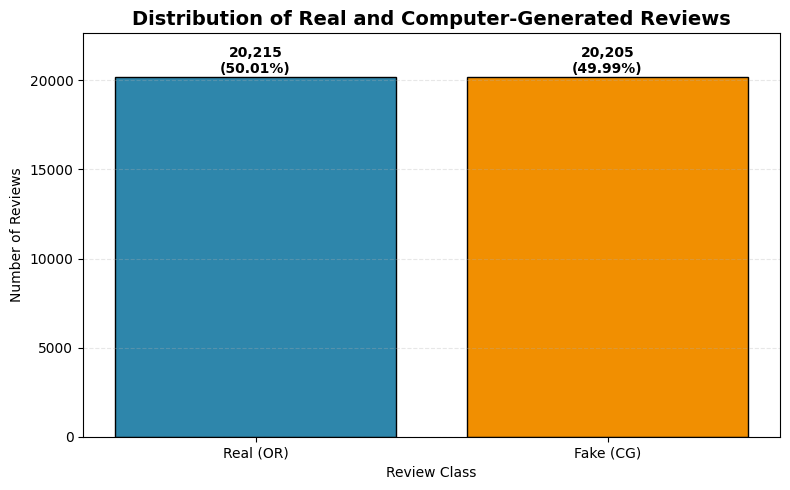

In [20]:
# Plot class distribution
class_counts = df["label"].value_counts().reindex(["OR", "CG"])
class_names = ["Real (OR)", "Fake (CG)"]
colors = ["#2E86AB", "#F18F01"]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    class_names,
    class_counts.values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Distribution of Real and Computer-Generated Reviews",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Review Class")
plt.ylabel("Number of Reviews")

for bar, count in zip(bars, class_counts.values):
    percentage = count / class_counts.sum() * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        fontweight="bold"
    )

plt.ylim(0, class_counts.max() * 1.12)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


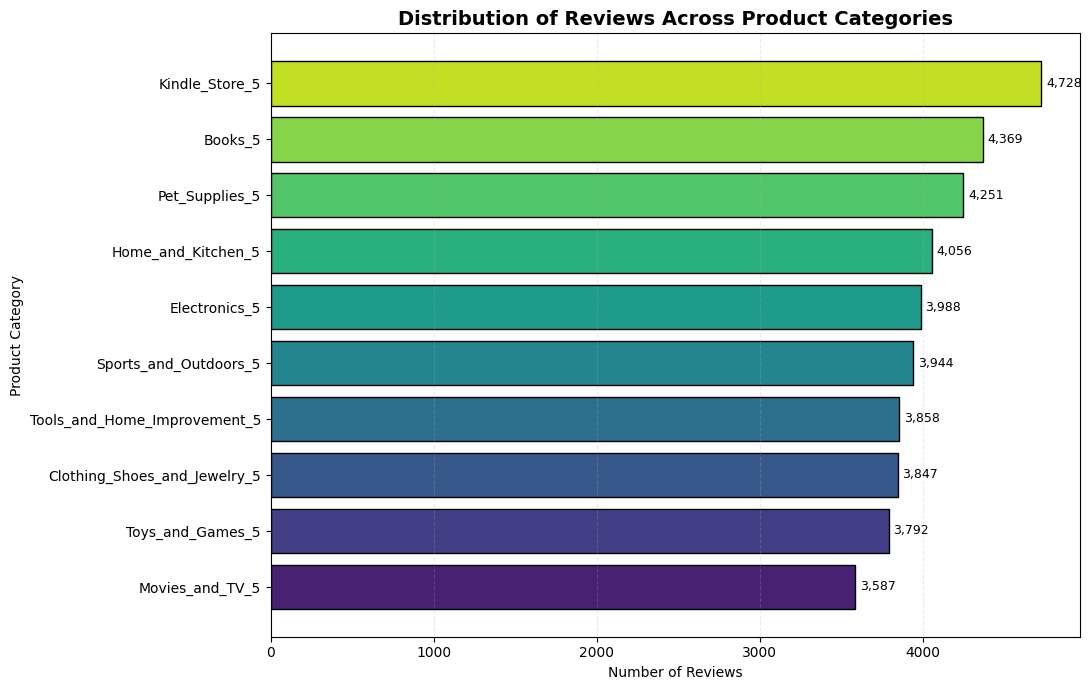

In [21]:
# Plot category distribution
category_plot = df["category"].value_counts().sort_values()

plt.figure(figsize=(11, 7))
colors = sns.color_palette("viridis", len(category_plot))

bars = plt.barh(
    category_plot.index,
    category_plot.values,
    color=colors,
    edgecolor="black"
)

plt.title(
    "Distribution of Reviews Across Product Categories",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Number of Reviews")
plt.ylabel("Product Category")

for bar in bars:
    value = int(bar.get_width())
    plt.text(
        value + 30,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}",
        va="center",
        fontsize=9
    )

plt.grid(axis="x", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()


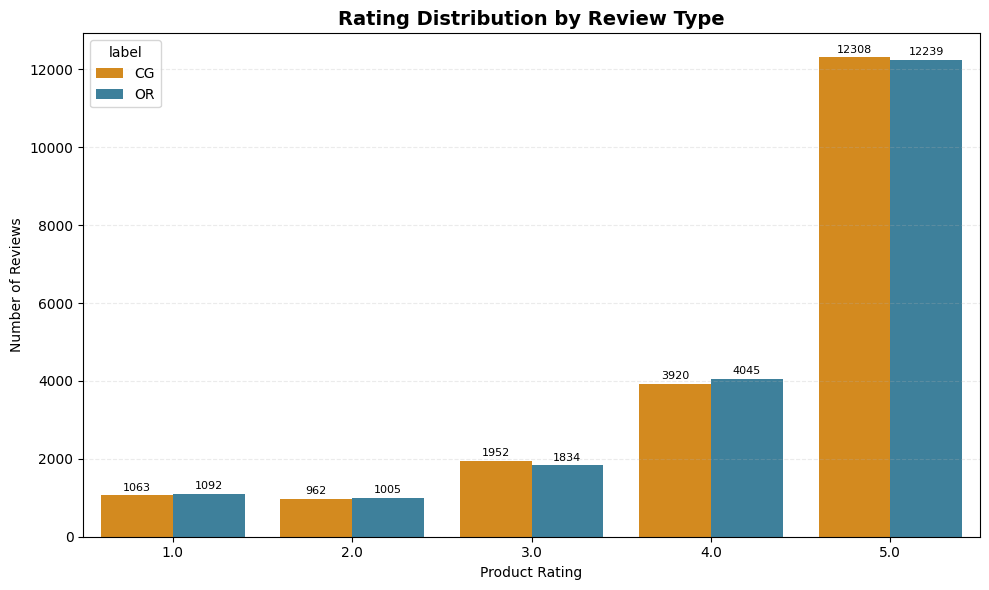

In [22]:
# Plot rating distribution by class
rating_class = (
    df.groupby(["rating", "label"])
      .size()
      .reset_index(name="Count")
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=rating_class,
    x="rating",
    y="Count",
    hue="label",
    palette={"OR": "#2E86AB", "CG": "#F18F01"}
)

plt.title(
    "Rating Distribution by Review Type",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Product Rating")
plt.ylabel("Number of Reviews")

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=8)

plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()


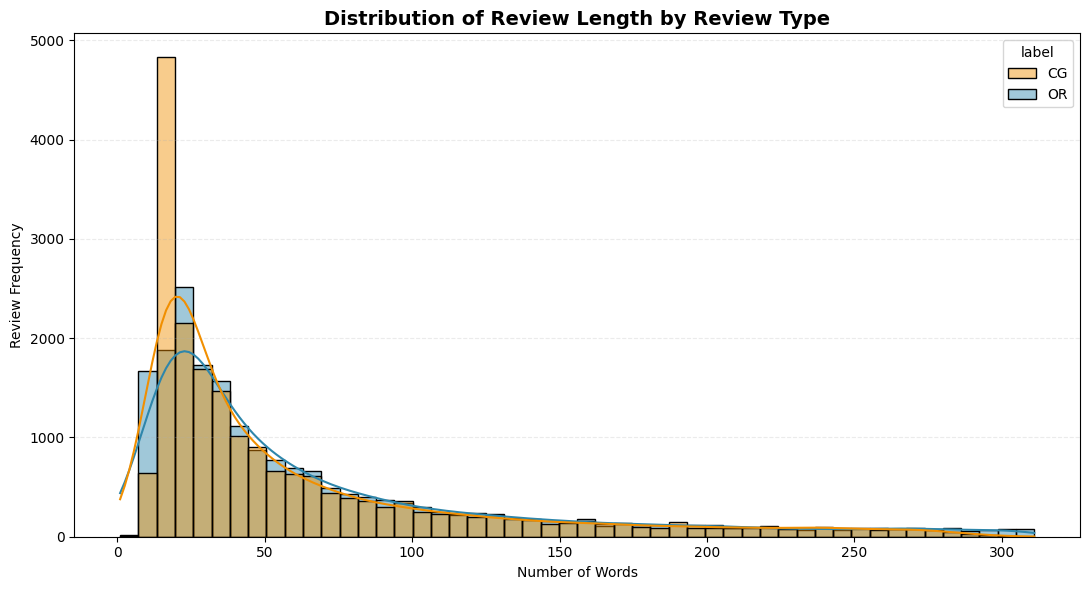

In [23]:
# Plot review length distribution
upper_limit = df["word_count"].quantile(0.99)

plt.figure(figsize=(11, 6))

sns.histplot(
    data=df[df["word_count"] <= upper_limit],
    x="word_count",
    hue="label",
    bins=50,
    kde=True,
    palette={"OR": "#2E86AB", "CG": "#F18F01"},
    alpha=0.45
)

plt.title(
    "Distribution of Review Length by Review Type",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Number of Words")
plt.ylabel("Review Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()


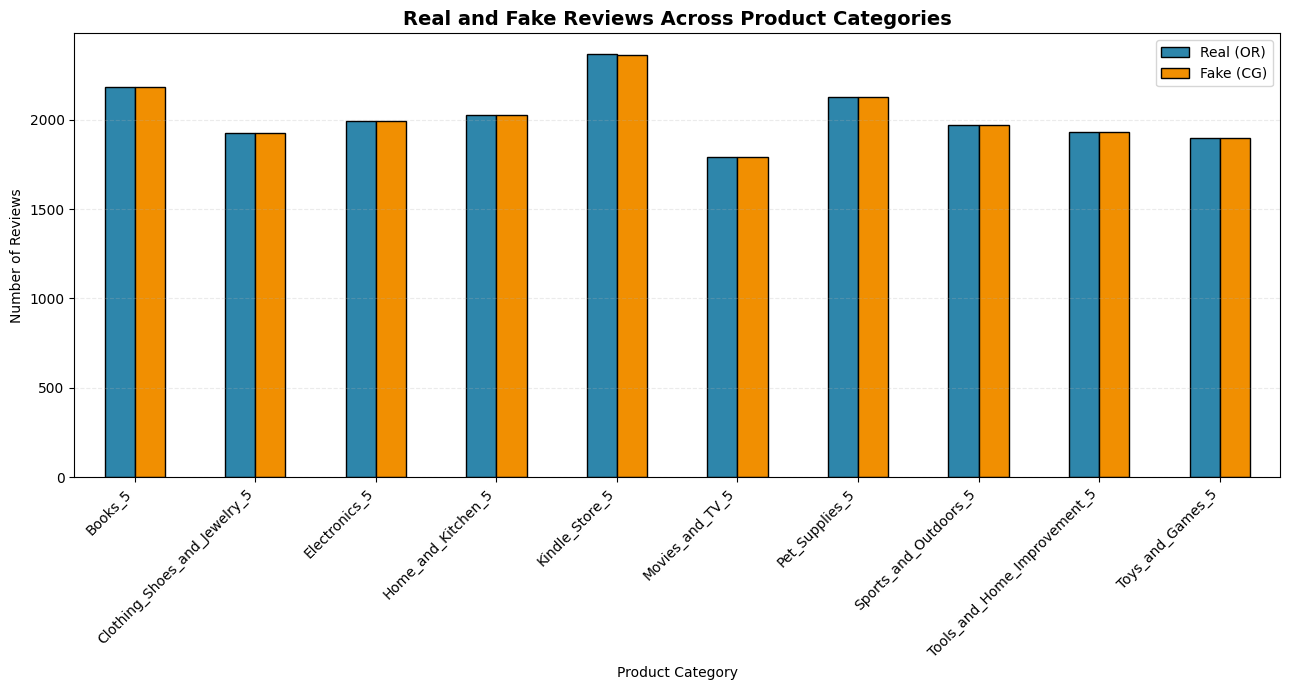

In [24]:
# Plot category-class distribution
category_label = pd.crosstab(
    df["category"],
    df["label"]
)[["OR", "CG"]]

category_label.columns = ["Real (OR)", "Fake (CG)"]

category_label.plot(
    kind="bar",
    figsize=(13, 7),
    color=["#2E86AB", "#F18F01"],
    edgecolor="black"
)

plt.title(
    "Real and Fake Reviews Across Product Categories",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.25)
plt.tight_layout()
plt.show()


### Word Clouds

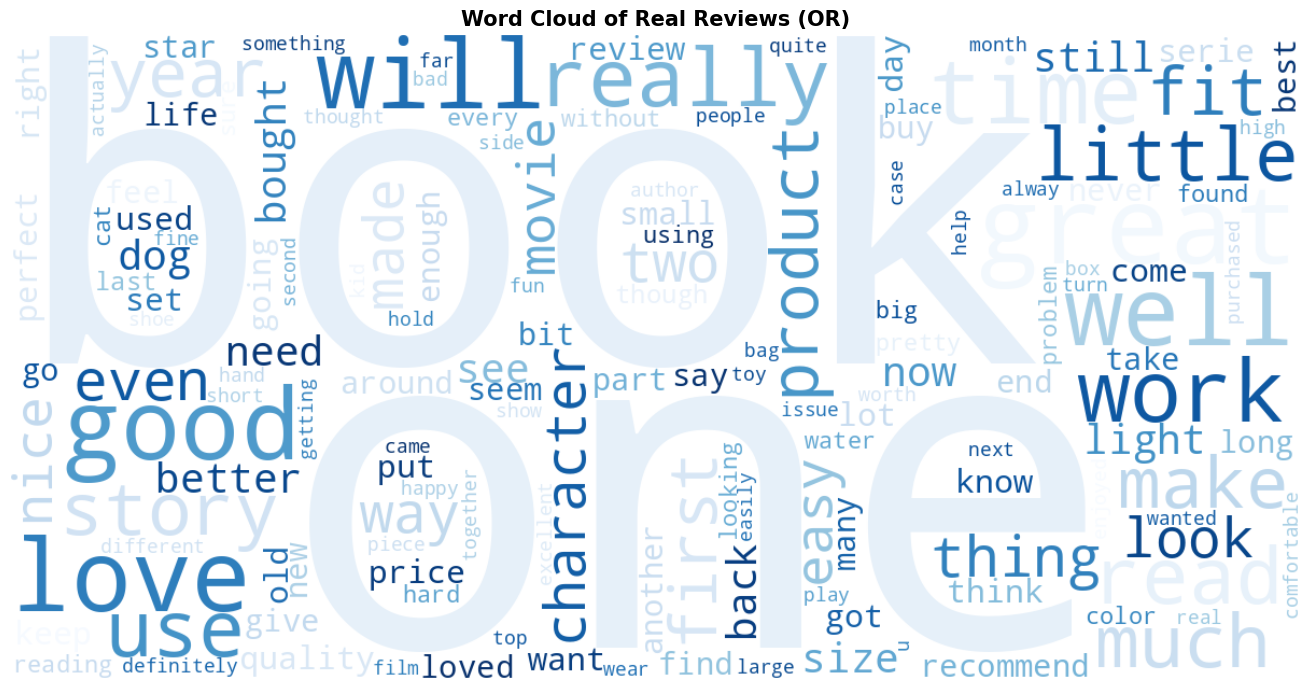

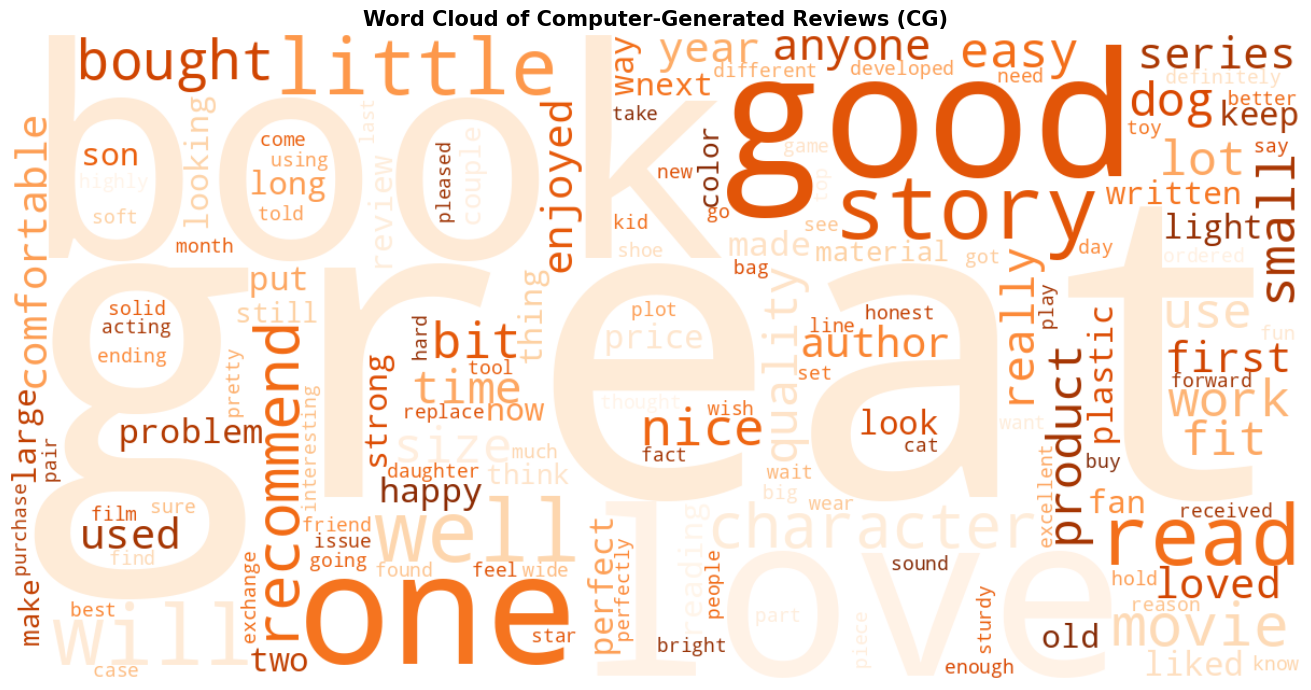

In [25]:
# Generate word clouds for real and fake reviews
real_text = " ".join(
    df.loc[df["label"] == "OR", "text_clean"].astype(str)
)

fake_text = " ".join(
    df.loc[df["label"] == "CG", "text_clean"].astype(str)
)

real_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Blues",
    max_words=150,
    collocations=False,
    random_state=SEED
).generate(real_text)

fake_wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="Oranges",
    max_words=150,
    collocations=False,
    random_state=SEED
).generate(fake_text)

plt.figure(figsize=(14, 7))
plt.imshow(real_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Word Cloud of Real Reviews (OR)",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
plt.imshow(fake_wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title(
    "Word Cloud of Computer-Generated Reviews (CG)",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


## Leakage-Safe Final Dataset

In [26]:
# Create canonical text representation
def canonicalize_text(text):
    text = str(text)
    text = unicodedata.normalize("NFKC", text)
    text = text.lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text_group"] = df["text_"].apply(canonicalize_text)

canonical_conflicts = (
    df.groupby("text_group")["target"]
      .nunique()
)

assert (canonical_conflicts <= 1).all(), (
    "Conflicting labels found among canonical duplicate texts."
)

df = (
    df.drop_duplicates(
        subset="text_group",
        keep="first"
    )
    .reset_index(drop=True)
)

clean_conflicts = (
    df.groupby("text_clean")["target"]
      .nunique()
)

assert (clean_conflicts <= 1).all(), (
    "Conflicting labels found among cleaned duplicate texts."
)

df = (
    df.drop_duplicates(
        subset="text_clean",
        keep="first"
    )
    .reset_index(drop=True)
)

df = (
    df.loc[
        ~df["text_clean"].str.strip().eq("")
    ]
    .reset_index(drop=True)
)

print("Final cleaned dataset shape:", df.shape)


Final cleaned dataset shape: (40385, 24)


In [27]:
# Create stratified 70/15/15 split
df["stratify_key"] = (
    df["target"].astype(str)
    + "_"
    + df["category"].astype(str)
)

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["stratify_key"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["stratify_key"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Training samples   : {len(train_df):,}")
print(f"Validation samples : {len(val_df):,}")
print(f"Testing samples    : {len(test_df):,}")


Training samples   : 28,269
Validation samples : 6,058
Testing samples    : 6,058


In [28]:
# Enforce zero cross-split leakage
def overlap_count(train_data, val_data, test_data, column):
    train_values = set(train_data[column])
    val_values = set(val_data[column])
    test_values = set(test_data[column])

    return {
        "Representation": column,
        "Train-Val": len(train_values & val_values),
        "Train-Test": len(train_values & test_values),
        "Val-Test": len(val_values & test_values)
    }

leakage_results = pd.DataFrame([
    overlap_count(train_df, val_df, test_df, "text_"),
    overlap_count(train_df, val_df, test_df, "text_group"),
    overlap_count(train_df, val_df, test_df, "text_clean"),
    overlap_count(train_df, val_df, test_df, "text_roberta")
])

display(leakage_results)

assert leakage_results[
    ["Train-Val", "Train-Test", "Val-Test"]
].to_numpy().sum() == 0, (
    "Cross-split text leakage detected."
)

print(
    "Leakage check passed: "
    "all text representations have zero overlap."
)


,Representation,Train-Val,Train-Test,Val-Test
0,text_,0,0,0
1,text_group,0,0,0
2,text_clean,0,0,0
3,text_roberta,0,0,0


Leakage check passed: all text representations have zero overlap.


## TF-IDF Feature Extraction

In [29]:
# Fit TF-IDF on training data only
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

X_train_tfidf = tfidf.fit_transform(
    train_df["text_clean"]
)

X_val_tfidf = tfidf.transform(
    val_df["text_clean"]
)

X_test_tfidf = tfidf.transform(
    test_df["text_clean"]
)

y_train = train_df["target"].values
y_val = val_df["target"].values
y_test = test_df["target"].values

print(f"Training matrix   : {X_train_tfidf.shape}")
print(f"Validation matrix : {X_val_tfidf.shape}")
print(f"Testing matrix    : {X_test_tfidf.shape}")


Training matrix   : (28269, 10000)
Validation matrix : (6058, 10000)
Testing matrix    : (6058, 10000)


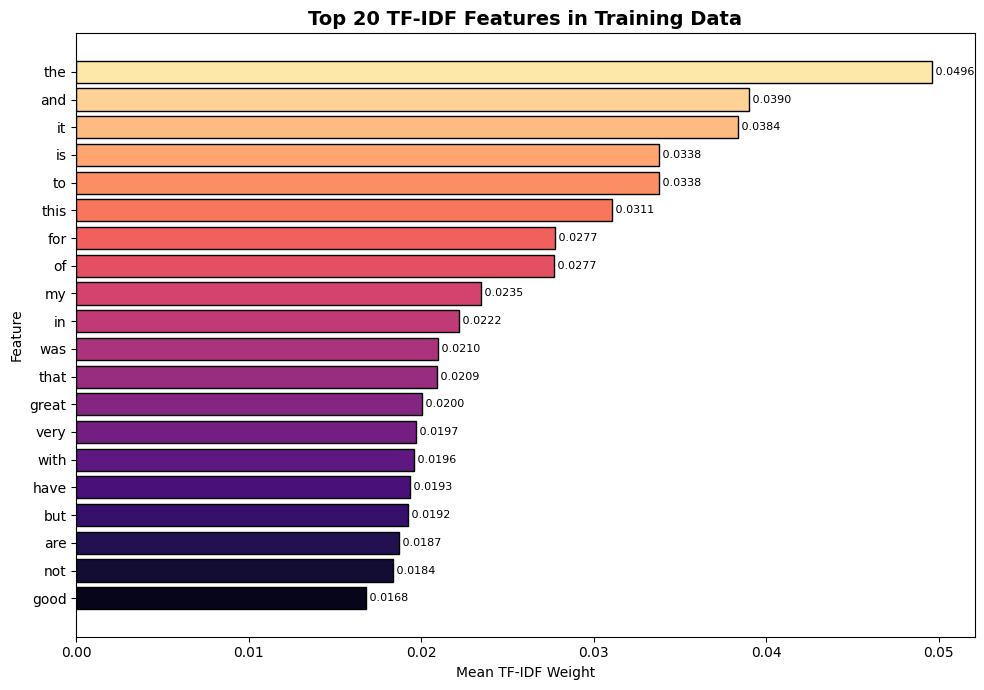

In [30]:
# Plot top TF-IDF features
feature_names = np.array(
    tfidf.get_feature_names_out()
)

mean_tfidf = np.asarray(
    X_train_tfidf.mean(axis=0)
).ravel()

top_indices = mean_tfidf.argsort()[-20:][::-1]

top_features = pd.DataFrame({
    "Feature": feature_names[top_indices],
    "Mean TF-IDF": mean_tfidf[top_indices]
})

plot_features = top_features.sort_values("Mean TF-IDF")

plt.figure(figsize=(10, 7))
colors = sns.color_palette("magma", len(plot_features))

bars = plt.barh(
    plot_features["Feature"],
    plot_features["Mean TF-IDF"],
    color=colors,
    edgecolor="black"
)

plt.title(
    "Top 20 TF-IDF Features in Training Data",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Mean TF-IDF Weight")
plt.ylabel("Feature")

for bar in bars:
    value = bar.get_width()
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()


## Shared Evaluation Functions

In [31]:
# Define evaluation functions
def evaluate_model(model_name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ) * 100
    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ) * 100
    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    ) * 100

    results = {
        "Model": model_name,
        "Accuracy (%)": accuracy,
        "Weighted Precision (%)": precision,
        "Weighted Recall (%)": recall,
        "Weighted F1 (%)": f1
    }

    print(f"\n{model_name}")
    print(f"Accuracy           : {accuracy:.2f}%")
    print(f"Weighted Precision : {precision:.2f}%")
    print(f"Weighted Recall    : {recall:.2f}%")
    print(f"Weighted F1-score  : {f1:.2f}%")

    return results


def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt=",d",
        cmap="Blues",
        linewidths=1,
        linecolor="white",
        xticklabels=["Real (0)", "Fake (1)"],
        yticklabels=["Real (0)", "Fake (1)"]
    )

    plt.title(
        f"{model_name} - Confusion Matrix",
        fontsize=14,
        fontweight="bold"
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")
    plt.tight_layout()
    plt.show()


def display_classification_report(y_true, y_pred):
    report = classification_report(
        y_true,
        y_pred,
        target_names=["Real (OR)", "Fake (CG)"],
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).T

    for column in [
        "precision",
        "recall",
        "f1-score"
    ]:
        report_df[column] *= 100

    display(report_df.round(2))


## Classical Machine-Learning Models



Decision Tree
Accuracy           : 76.33%
Weighted Precision : 76.33%
Weighted Recall    : 76.33%
Weighted F1-score  : 76.33%


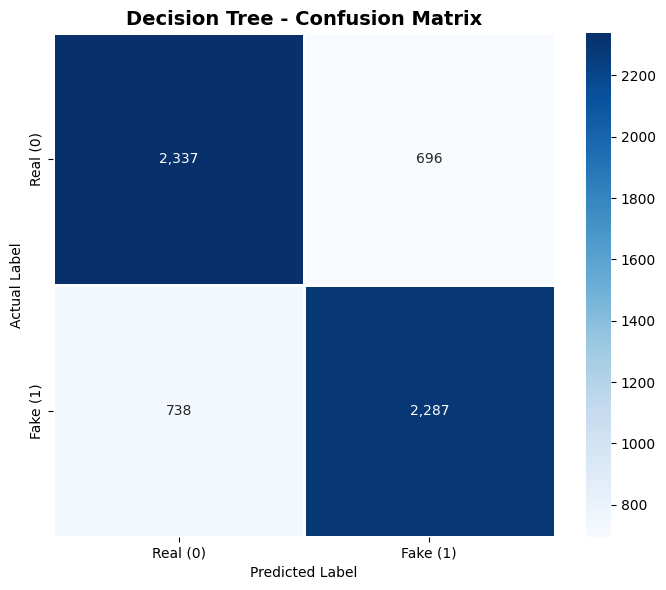

,precision,recall,f1-score,support
Real (OR),76.00,77.05,76.52,3033.00
Fake (CG),76.67,75.60,76.13,3025.00
accuracy,76.33,76.33,76.33,0.76
macro avg,76.33,76.33,76.33,6058.00
weighted avg,76.33,76.33,76.33,6058.00


In [32]:
# Decision Tree
decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=50,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=SEED
)

decision_tree.fit(
    X_train_tfidf,
    y_train
)

dt_test_pred = decision_tree.predict(
    X_test_tfidf
)

dt_results = evaluate_model(
    "Decision Tree",
    y_test,
    dt_test_pred
)

plot_confusion_matrix(
    y_test,
    dt_test_pred,
    "Decision Tree"
)

display_classification_report(
    y_test,
    dt_test_pred
)



Random Forest
Accuracy           : 90.26%
Weighted Precision : 90.31%
Weighted Recall    : 90.26%
Weighted F1-score  : 90.26%


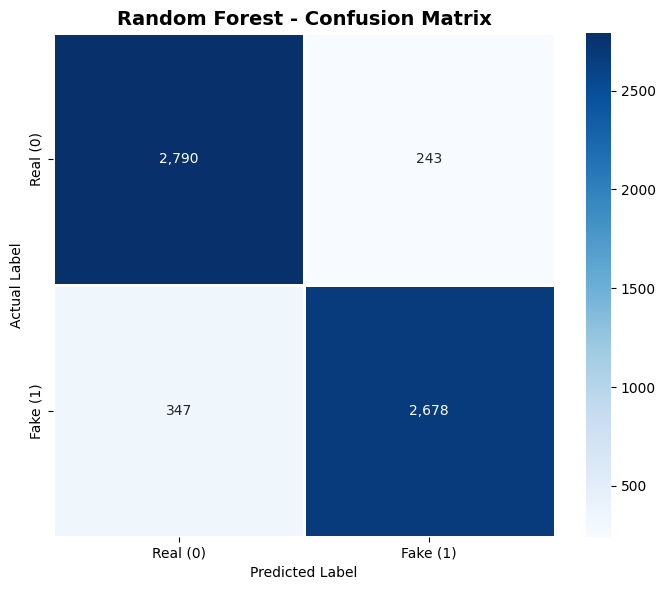

,precision,recall,f1-score,support
Real (OR),88.94,91.99,90.44,3033.0
Fake (CG),91.68,88.53,90.08,3025.0
accuracy,90.26,90.26,90.26,0.9
macro avg,90.31,90.26,90.26,6058.0
weighted avg,90.31,90.26,90.26,6058.0


In [33]:
# Random Forest
random_forest = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=3,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEED
)

random_forest.fit(
    X_train_tfidf,
    y_train
)

rf_test_pred = random_forest.predict(
    X_test_tfidf
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_test_pred
)

plot_confusion_matrix(
    y_test,
    rf_test_pred,
    "Random Forest"
)

display_classification_report(
    y_test,
    rf_test_pred
)



Gradient Boosting
Accuracy           : 83.25%
Weighted Precision : 83.40%
Weighted Recall    : 83.25%
Weighted F1-score  : 83.23%


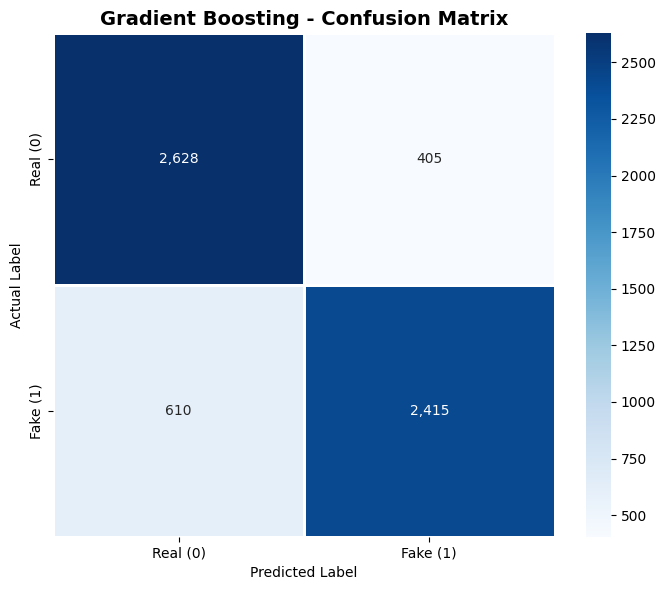

,precision,recall,f1-score,support
Real (OR),81.16,86.65,83.81,3033.00
Fake (CG),85.64,79.83,82.63,3025.00
accuracy,83.25,83.25,83.25,0.83
macro avg,83.40,83.24,83.22,6058.00
weighted avg,83.40,83.25,83.23,6058.00


In [34]:
# Gradient Boosting
gradient_boosting = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=SEED
)

gradient_boosting.fit(
    X_train_tfidf,
    y_train
)

gb_test_pred = gradient_boosting.predict(
    X_test_tfidf
)

gb_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gb_test_pred
)

plot_confusion_matrix(
    y_test,
    gb_test_pred,
    "Gradient Boosting"
)

display_classification_report(
    y_test,
    gb_test_pred
)


In [35]:
# Compare classical models
classical_results = pd.DataFrame([
    dt_results,
    rf_results,
    gb_results
])

metric_columns = [
    "Accuracy (%)",
    "Weighted Precision (%)",
    "Weighted Recall (%)",
    "Weighted F1 (%)"
]

classical_results[
    metric_columns
] = classical_results[
    metric_columns
].round(2)

display(classical_results)


,Model,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1 (%)
0,Decision Tree,76.33,76.33,76.33,76.33
1,Random Forest,90.26,90.31,90.26,90.26
2,Gradient Boosting,83.25,83.40,83.25,83.23


## Deep-Learning Setup

In [36]:
# Import deep learning libraries
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
    )
else:
    print(
        "GPU not detected. "
        "Transformer models will run on CPU."
    )


Device: cuda
GPU: Tesla T4
GPU memory: 15.64 GB


## RoBERTa Tokenisation and Sequence-Length Analysis

In [37]:
# Load RoBERTa tokenizer
MODEL_NAME = "FacebookAI/roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

print("Tokenizer loaded successfully.")
print("Vocabulary size:", tokenizer.vocab_size)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer loaded successfully.
Vocabulary size: 50265


In [38]:
# Calculate token lengths
def get_token_length(text):
    return len(
        tokenizer.encode(
            text,
            add_special_tokens=True,
            truncation=False
        )
    )

roberta_token_lengths = (
    df["text_roberta"]
      .apply(get_token_length)
)

token_stats = (
    roberta_token_lengths
    .describe(
        percentiles=[
            0.50,
            0.75,
            0.80,
            0.85,
            0.90,
            0.95,
            0.97,
            0.99
        ]
    )
    .round(2)
)

display(
    token_stats.to_frame(
        "RoBERTa Token Count"
    )
)


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (530 > 512). Running this sequence through the model will result in indexing errors


,RoBERTa Token Count
count,40385.00
mean,81.96
std,82.86
min,4.00
50%,47.00
75%,102.00
80%,125.00
85%,158.00
90%,205.00
95%,278.00


In [39]:
# Compare candidate sequence lengths
candidate_lengths = [
    64,
    128,
    192,
    256,
    384,
    512
]

coverage_results = []

for length in candidate_lengths:
    covered = (
        roberta_token_lengths <= length
    ).mean() * 100

    coverage_results.append({
        "Max Length": length,
        "Reviews Fully Covered (%)": covered,
        "Reviews Truncated (%)": 100 - covered
    })

coverage_df = pd.DataFrame(
    coverage_results
)

coverage_df[
    [
        "Reviews Fully Covered (%)",
        "Reviews Truncated (%)"
    ]
] = coverage_df[
    [
        "Reviews Fully Covered (%)",
        "Reviews Truncated (%)"
    ]
].round(2)

display(coverage_df)

MAX_LENGTH = 256

print(
    f"Selected MAX_LENGTH: {MAX_LENGTH}"
)


,Max Length,Reviews Fully Covered (%),Reviews Truncated (%)
0,64,61.14,38.86
1,128,80.63,19.37
2,192,88.83,11.17
3,256,93.69,6.31
4,384,99.21,0.79
5,512,99.99,0.01


Selected MAX_LENGTH: 256


## Transformer Dataset and DataLoaders

In [40]:
# Create transformer dataset
class ReviewDataset(Dataset):

    def __init__(
        self,
        texts,
        labels,
        tokenizer,
        max_length
    ):
        self.texts = texts.astype(str).tolist()
        self.labels = np.asarray(labels, dtype=np.int64)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }


In [41]:
# Create datasets and DataLoaders
train_dataset = ReviewDataset(
    train_df["text_roberta"],
    train_df["target"],
    tokenizer,
    MAX_LENGTH
)

val_dataset = ReviewDataset(
    val_df["text_roberta"],
    val_df["target"],
    tokenizer,
    MAX_LENGTH
)

test_dataset = ReviewDataset(
    test_df["text_roberta"],
    test_df["target"],
    tokenizer,
    MAX_LENGTH
)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

generator = torch.Generator()
generator.manual_seed(SEED)

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print(f"Training dataset   : {len(train_dataset):,}")
print(f"Validation dataset : {len(val_dataset):,}")
print(f"Testing dataset    : {len(test_dataset):,}")


Training dataset   : 28,269
Validation dataset : 6,058
Testing dataset    : 6,058


## Frozen RoBERTa Feature Extractor

In [42]:
# Load and freeze RoBERTa
roberta = AutoModel.from_pretrained(
    MODEL_NAME
).to(device)

for parameter in roberta.parameters():
    parameter.requires_grad = False

roberta.eval()

print("RoBERTa encoder loaded and frozen.")
print("Hidden size:", roberta.config.hidden_size)


model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa encoder loaded and frozen.
Hidden size: 768


In [43]:
# Mixed precision setting
USE_AMP = device.type == "cuda"

print(
    "Mixed precision enabled:",
    USE_AMP
)


Mixed precision enabled: True


## Shared Deep-Learning Functions

In [44]:
# Define training and validation functions
def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device
):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_predictions = []

    for batch in loader:
        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )
        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            logits = model(
                input_ids,
                attention_mask
            )
            loss = criterion(
                logits,
                labels
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            filter(
                lambda p: p.requires_grad,
                model.parameters()
            ),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * labels.size(0)

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )
        all_predictions.extend(
            predictions.detach().cpu().numpy()
        )

    epoch_loss = running_loss / len(loader.dataset)

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    ) * 100

    return epoch_loss, epoch_f1


def validate_epoch(
    model,
    loader,
    criterion,
    device
):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(
                device,
                non_blocking=True
            )
            attention_mask = batch["attention_mask"].to(
                device,
                non_blocking=True
            )
            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP
            ):
                logits = model(
                    input_ids,
                    attention_mask
                )
                loss = criterion(
                    logits,
                    labels
                )

            running_loss += loss.item() * labels.size(0)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    ) * 100

    return epoch_loss, epoch_f1


def predict_deep_model(
    model,
    loader,
    device
):
    model.eval()
    labels_all = []
    predictions_all = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(
                device,
                non_blocking=True
            )
            attention_mask = batch["attention_mask"].to(
                device,
                non_blocking=True
            )
            labels = batch["labels"].to(device)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP
            ):
                logits = model(
                    input_ids,
                    attention_mask
                )

            predictions = torch.argmax(
                logits,
                dim=1
            )

            labels_all.extend(labels.cpu().numpy())
            predictions_all.extend(predictions.cpu().numpy())

    return (
        np.array(labels_all),
        np.array(predictions_all)
    )


## RoBERTa Features + Bidirectional LSTM

In [45]:
# Define RoBERTa-BiLSTM
class RobertaBiLSTM(nn.Module):

    def __init__(
        self,
        roberta_model,
        hidden_size=128,
        dropout=0.30,
        num_classes=2
    ):
        super().__init__()

        self.roberta = roberta_model

        for parameter in self.roberta.parameters():
            parameter.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=self.roberta.config.hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 128)
        self.relu = nn.ReLU()
        self.classifier = nn.Linear(128, num_classes)

    def forward(
        self,
        input_ids,
        attention_mask
    ):
        self.roberta.eval()

        with torch.no_grad():
            outputs = self.roberta(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            sequence_features = outputs.last_hidden_state

        lengths = attention_mask.sum(dim=1).cpu()

        packed_features = nn.utils.rnn.pack_padded_sequence(
            sequence_features,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(
            packed_features
        )

        combined_hidden = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1
        )

        x = self.dropout(combined_hidden)
        x = self.relu(self.fc(x))
        x = self.dropout(x)

        return self.classifier(x)


In [46]:
# Train RoBERTa-BiLSTM
roberta_lstm = RobertaBiLSTM(
    roberta_model=roberta,
    hidden_size=128,
    dropout=0.30,
    num_classes=2
).to(device)

criterion_lstm = nn.CrossEntropyLoss()

optimizer_lstm = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        roberta_lstm.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

scaler_lstm = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

LSTM_EPOCHS = 10
LSTM_PATIENCE = 3

best_lstm_val_loss = float("inf")
lstm_patience_counter = 0
best_lstm_state = None

history_lstm = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(1, LSTM_EPOCHS + 1):
    train_loss, train_f1 = train_epoch(
        roberta_lstm,
        train_loader,
        optimizer_lstm,
        criterion_lstm,
        scaler_lstm,
        device
    )

    val_loss, val_f1 = validate_epoch(
        roberta_lstm,
        val_loader,
        criterion_lstm,
        device
    )

    history_lstm["train_loss"].append(train_loss)
    history_lstm["val_loss"].append(val_loss)
    history_lstm["train_f1"].append(train_f1)
    history_lstm["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch:02d}/{LSTM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train F1: {train_f1:.2f}% | "
        f"Val F1: {val_f1:.2f}%"
    )

    if val_loss < best_lstm_val_loss:
        best_lstm_val_loss = val_loss
        lstm_patience_counter = 0

        best_lstm_state = {
            key: value.detach().cpu().clone()
            for key, value
            in roberta_lstm.state_dict().items()
        }
    else:
        lstm_patience_counter += 1

        if lstm_patience_counter >= LSTM_PATIENCE:
            print("Early stopping triggered.")
            break

roberta_lstm.load_state_dict(best_lstm_state)
roberta_lstm = roberta_lstm.to(device)


Epoch 01/10 | Train Loss: 0.1661 | Val Loss: 0.0868 | Train F1: 93.42% | Val F1: 96.81%
Epoch 02/10 | Train Loss: 0.0880 | Val Loss: 0.1022 | Train F1: 96.99% | Val F1: 96.73%
Epoch 03/10 | Train Loss: 0.0596 | Val Loss: 0.0914 | Train F1: 98.09% | Val F1: 96.88%
Epoch 04/10 | Train Loss: 0.0382 | Val Loss: 0.1304 | Train F1: 98.80% | Val F1: 96.61%
Early stopping triggered.



RoBERTa + BiLSTM
Accuracy           : 95.97%
Weighted Precision : 95.99%
Weighted Recall    : 95.97%
Weighted F1-score  : 95.97%


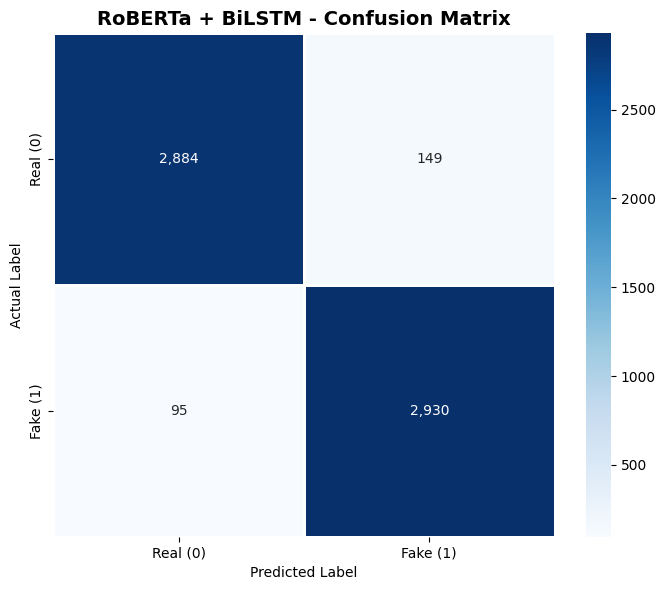

,precision,recall,f1-score,support
Real (OR),96.81,95.09,95.94,3033.00
Fake (CG),95.16,96.86,96.00,3025.00
accuracy,95.97,95.97,95.97,0.96
macro avg,95.99,95.97,95.97,6058.00
weighted avg,95.99,95.97,95.97,6058.00


In [47]:
# Evaluate RoBERTa-BiLSTM
lstm_y_true, lstm_test_pred = predict_deep_model(
    roberta_lstm,
    test_loader,
    device
)

lstm_results = evaluate_model(
    "RoBERTa + BiLSTM",
    lstm_y_true,
    lstm_test_pred
)

plot_confusion_matrix(
    lstm_y_true,
    lstm_test_pred,
    "RoBERTa + BiLSTM"
)

display_classification_report(
    lstm_y_true,
    lstm_test_pred
)


## RoBERTa Features + Bidirectional GRU

In [48]:
# Define RoBERTa-BiGRU
class RobertaBiGRU(nn.Module):

    def __init__(
        self,
        roberta_model,
        hidden_size=128,
        dropout=0.30,
        num_classes=2
    ):
        super().__init__()

        self.roberta = roberta_model

        for parameter in self.roberta.parameters():
            parameter.requires_grad = False

        self.gru = nn.GRU(
            input_size=self.roberta.config.hidden_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, 128)
        self.relu = nn.ReLU()
        self.classifier = nn.Linear(128, num_classes)

    def forward(
        self,
        input_ids,
        attention_mask
    ):
        self.roberta.eval()

        with torch.no_grad():
            outputs = self.roberta(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            sequence_features = outputs.last_hidden_state

        lengths = attention_mask.sum(dim=1).cpu()

        packed_features = nn.utils.rnn.pack_padded_sequence(
            sequence_features,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        _, hidden = self.gru(
            packed_features
        )

        combined_hidden = torch.cat(
            (hidden[-2], hidden[-1]),
            dim=1
        )

        x = self.dropout(combined_hidden)
        x = self.relu(self.fc(x))
        x = self.dropout(x)

        return self.classifier(x)


In [49]:
# Train RoBERTa-BiGRU
roberta_gru = RobertaBiGRU(
    roberta_model=roberta,
    hidden_size=128,
    dropout=0.30,
    num_classes=2
).to(device)

criterion_gru = nn.CrossEntropyLoss()

optimizer_gru = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        roberta_gru.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)

scaler_gru = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

GRU_EPOCHS = 10
GRU_PATIENCE = 3

best_gru_val_loss = float("inf")
gru_patience_counter = 0
best_gru_state = None

history_gru = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(1, GRU_EPOCHS + 1):
    train_loss, train_f1 = train_epoch(
        roberta_gru,
        train_loader,
        optimizer_gru,
        criterion_gru,
        scaler_gru,
        device
    )

    val_loss, val_f1 = validate_epoch(
        roberta_gru,
        val_loader,
        criterion_gru,
        device
    )

    history_gru["train_loss"].append(train_loss)
    history_gru["val_loss"].append(val_loss)
    history_gru["train_f1"].append(train_f1)
    history_gru["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch:02d}/{GRU_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train F1: {train_f1:.2f}% | "
        f"Val F1: {val_f1:.2f}%"
    )

    if val_loss < best_gru_val_loss:
        best_gru_val_loss = val_loss
        gru_patience_counter = 0

        best_gru_state = {
            key: value.detach().cpu().clone()
            for key, value
            in roberta_gru.state_dict().items()
        }
    else:
        gru_patience_counter += 1

        if gru_patience_counter >= GRU_PATIENCE:
            print("Early stopping triggered.")
            break

roberta_gru.load_state_dict(best_gru_state)
roberta_gru = roberta_gru.to(device)


Epoch 01/10 | Train Loss: 0.1480 | Val Loss: 0.0823 | Train F1: 94.05% | Val F1: 96.60%
Epoch 02/10 | Train Loss: 0.0706 | Val Loss: 0.0669 | Train F1: 97.57% | Val F1: 97.49%
Epoch 03/10 | Train Loss: 0.0408 | Val Loss: 0.0750 | Train F1: 98.63% | Val F1: 97.62%
Epoch 04/10 | Train Loss: 0.0266 | Val Loss: 0.0955 | Train F1: 99.23% | Val F1: 97.57%
Epoch 05/10 | Train Loss: 0.0205 | Val Loss: 0.1306 | Train F1: 99.35% | Val F1: 97.66%
Early stopping triggered.



RoBERTa + BiGRU
Accuracy           : 97.67%
Weighted Precision : 97.68%
Weighted Recall    : 97.67%
Weighted F1-score  : 97.67%


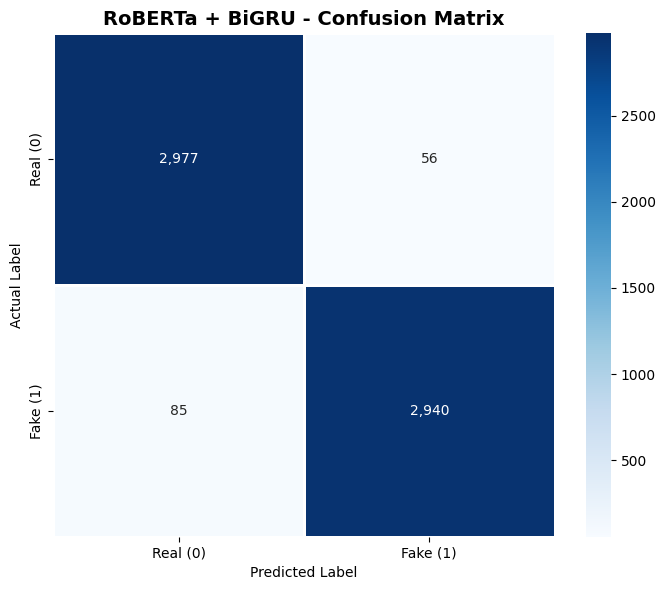

,precision,recall,f1-score,support
Real (OR),97.22,98.15,97.69,3033.00
Fake (CG),98.13,97.19,97.66,3025.00
accuracy,97.67,97.67,97.67,0.98
macro avg,97.68,97.67,97.67,6058.00
weighted avg,97.68,97.67,97.67,6058.00


In [50]:
# Evaluate RoBERTa-BiGRU
gru_y_true, gru_test_pred = predict_deep_model(
    roberta_gru,
    test_loader,
    device
)

gru_results = evaluate_model(
    "RoBERTa + BiGRU",
    gru_y_true,
    gru_test_pred
)

plot_confusion_matrix(
    gru_y_true,
    gru_test_pred,
    "RoBERTa + BiGRU"
)

display_classification_report(
    gru_y_true,
    gru_test_pred
)


## RoBERTa Fine-Tuning

In [51]:
# Release frozen recurrent models
del roberta_lstm
del roberta_gru
del roberta

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Frozen recurrent models released from memory.")


Frozen recurrent models released from memory.


In [52]:
# Load fresh RoBERTa classifier
roberta_ft = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
).to(device)

print(
    "Trainable parameters:",
    f"{sum(p.numel() for p in roberta_ft.parameters() if p.requires_grad):,}"
)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable parameters: 124,647,170


In [53]:
# Create fine-tuning DataLoaders
FT_BATCH_SIZE = 8

ft_generator = torch.Generator()
ft_generator.manual_seed(SEED)

ft_train_loader = DataLoader(
    train_dataset,
    batch_size=FT_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=ft_generator
)

ft_val_loader = DataLoader(
    val_dataset,
    batch_size=FT_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

ft_test_loader = DataLoader(
    test_dataset,
    batch_size=FT_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)


In [54]:
# Configure fine-tuning
FT_EPOCHS = 5
FT_PATIENCE = 2
FT_LEARNING_RATE = 2e-5
FT_WEIGHT_DECAY = 0.01
GRAD_ACCUM_STEPS = 2

optimizer_ft = torch.optim.AdamW(
    roberta_ft.parameters(),
    lr=FT_LEARNING_RATE,
    weight_decay=FT_WEIGHT_DECAY
)

updates_per_epoch = int(
    np.ceil(
        len(ft_train_loader)
        / GRAD_ACCUM_STEPS
    )
)

total_training_steps = (
    updates_per_epoch
    * FT_EPOCHS
)

warmup_steps = int(
    total_training_steps * 0.10
)

scheduler_ft = get_linear_schedule_with_warmup(
    optimizer_ft,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

scaler_ft = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print(
    f"Effective batch size: "
    f"{FT_BATCH_SIZE * GRAD_ACCUM_STEPS}"
)


Effective batch size: 16


In [55]:
# Define RoBERTa fine-tuning functions
def train_roberta_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    scaler,
    device,
    accumulation_steps
):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_predictions = []

    optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(loader, start=1):
        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )
        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )
        labels = batch["labels"].to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type=device.type,
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            raw_loss = outputs.loss
            loss = raw_loss / accumulation_steps
            logits = outputs.logits

        scaler.scale(loss).backward()

        if (
            step % accumulation_steps == 0
            or step == len(loader)
        ):
            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        running_loss += raw_loss.item() * labels.size(0)

        predictions = torch.argmax(
            logits,
            dim=1
        )

        all_labels.extend(labels.detach().cpu().numpy())
        all_predictions.extend(predictions.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    ) * 100

    return epoch_loss, epoch_f1


def validate_roberta(
    model,
    loader,
    device
):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(
                device,
                non_blocking=True
            )
            attention_mask = batch["attention_mask"].to(
                device,
                non_blocking=True
            )
            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP
            ):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )

                loss = outputs.loss
                logits = outputs.logits

            running_loss += loss.item() * labels.size(0)

            predictions = torch.argmax(
                logits,
                dim=1
            )

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)

    epoch_f1 = f1_score(
        all_labels,
        all_predictions,
        average="weighted",
        zero_division=0
    ) * 100

    return epoch_loss, epoch_f1


In [56]:
# Fine-tune RoBERTa
best_ft_val_loss = float("inf")
ft_patience_counter = 0
best_ft_state = None

history_ft = {
    "train_loss": [],
    "val_loss": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(1, FT_EPOCHS + 1):
    train_loss, train_f1 = train_roberta_epoch(
        roberta_ft,
        ft_train_loader,
        optimizer_ft,
        scheduler_ft,
        scaler_ft,
        device,
        GRAD_ACCUM_STEPS
    )

    val_loss, val_f1 = validate_roberta(
        roberta_ft,
        ft_val_loader,
        device
    )

    history_ft["train_loss"].append(train_loss)
    history_ft["val_loss"].append(val_loss)
    history_ft["train_f1"].append(train_f1)
    history_ft["val_f1"].append(val_f1)

    print(
        f"Epoch {epoch:02d}/{FT_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train F1: {train_f1:.2f}% | "
        f"Val F1: {val_f1:.2f}%"
    )

    if val_loss < best_ft_val_loss:
        best_ft_val_loss = val_loss
        ft_patience_counter = 0

        best_ft_state = {
            key: value.detach().cpu().clone()
            for key, value
            in roberta_ft.state_dict().items()
        }
    else:
        ft_patience_counter += 1

        if ft_patience_counter >= FT_PATIENCE:
            print("Early stopping triggered.")
            break

roberta_ft.load_state_dict(best_ft_state)
roberta_ft = roberta_ft.to(device)


Epoch 01/5 | Train Loss: 0.2281 | Val Loss: 0.1294 | Train F1: 90.74% | Val F1: 96.38%
Epoch 02/5 | Train Loss: 0.0713 | Val Loss: 0.0728 | Train F1: 98.33% | Val F1: 98.42%
Epoch 03/5 | Train Loss: 0.0305 | Val Loss: 0.1594 | Train F1: 99.32% | Val F1: 97.14%
Epoch 04/5 | Train Loss: 0.0144 | Val Loss: 0.1848 | Train F1: 99.69% | Val F1: 97.37%
Early stopping triggered.


In [57]:
# Define fine-tuned RoBERTa prediction
def predict_roberta(
    model,
    loader,
    device
):
    model.eval()
    true_labels = []
    predictions = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(
                device,
                non_blocking=True
            )
            attention_mask = batch["attention_mask"].to(
                device,
                non_blocking=True
            )
            labels = batch["labels"].to(device)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=USE_AMP
            ):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask
                )

                logits = outputs.logits

            batch_predictions = torch.argmax(
                logits,
                dim=1
            )

            true_labels.extend(labels.cpu().numpy())
            predictions.extend(batch_predictions.cpu().numpy())

    return (
        np.array(true_labels),
        np.array(predictions)
    )



Fine-Tuned RoBERTa
Accuracy           : 98.04%
Weighted Precision : 98.05%
Weighted Recall    : 98.04%
Weighted F1-score  : 98.04%


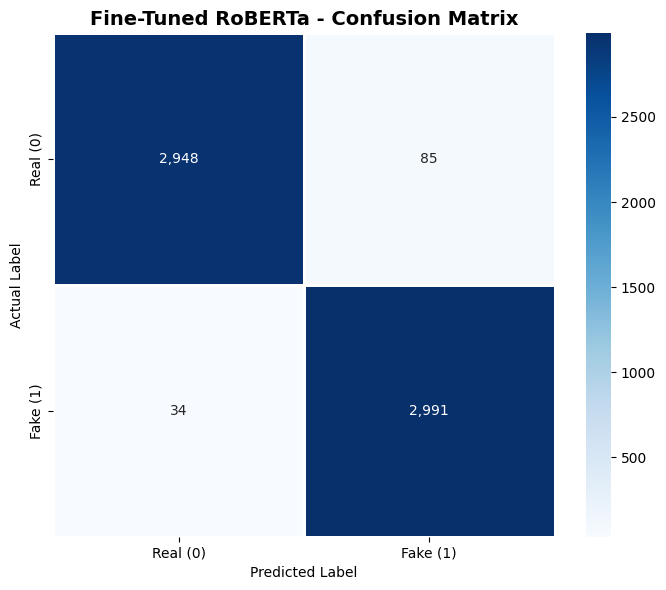

,precision,recall,f1-score,support
Real (OR),98.86,97.20,98.02,3033.00
Fake (CG),97.24,98.88,98.05,3025.00
accuracy,98.04,98.04,98.04,0.98
macro avg,98.05,98.04,98.04,6058.00
weighted avg,98.05,98.04,98.04,6058.00


In [58]:
# Evaluate fine-tuned RoBERTa
ft_y_true, ft_test_pred = predict_roberta(
    roberta_ft,
    ft_test_loader,
    device
)

roberta_ft_results = evaluate_model(
    "Fine-Tuned RoBERTa",
    ft_y_true,
    ft_test_pred
)

plot_confusion_matrix(
    ft_y_true,
    ft_test_pred,
    "Fine-Tuned RoBERTa"
)

display_classification_report(
    ft_y_true,
    ft_test_pred
)


## Final Model Comparison

In [59]:
# Compare all models
final_results = pd.DataFrame([
    dt_results,
    rf_results,
    gb_results,
    lstm_results,
    gru_results,
    roberta_ft_results
])

final_results[
    metric_columns
] = final_results[
    metric_columns
].round(2)

final_results = (
    final_results
    .sort_values(
        by="Weighted F1 (%)",
        ascending=False
    )
    .reset_index(drop=True)
)

display(final_results)


,Model,Accuracy (%),Weighted Precision (%),Weighted Recall (%),Weighted F1 (%)
0,Fine-Tuned RoBERTa,98.04,98.05,98.04,98.04
1,RoBERTa + BiGRU,97.67,97.68,97.67,97.67
2,RoBERTa + BiLSTM,95.97,95.99,95.97,95.97
3,Random Forest,90.26,90.31,90.26,90.26
4,Gradient Boosting,83.25,83.40,83.25,83.23
5,Decision Tree,76.33,76.33,76.33,76.33


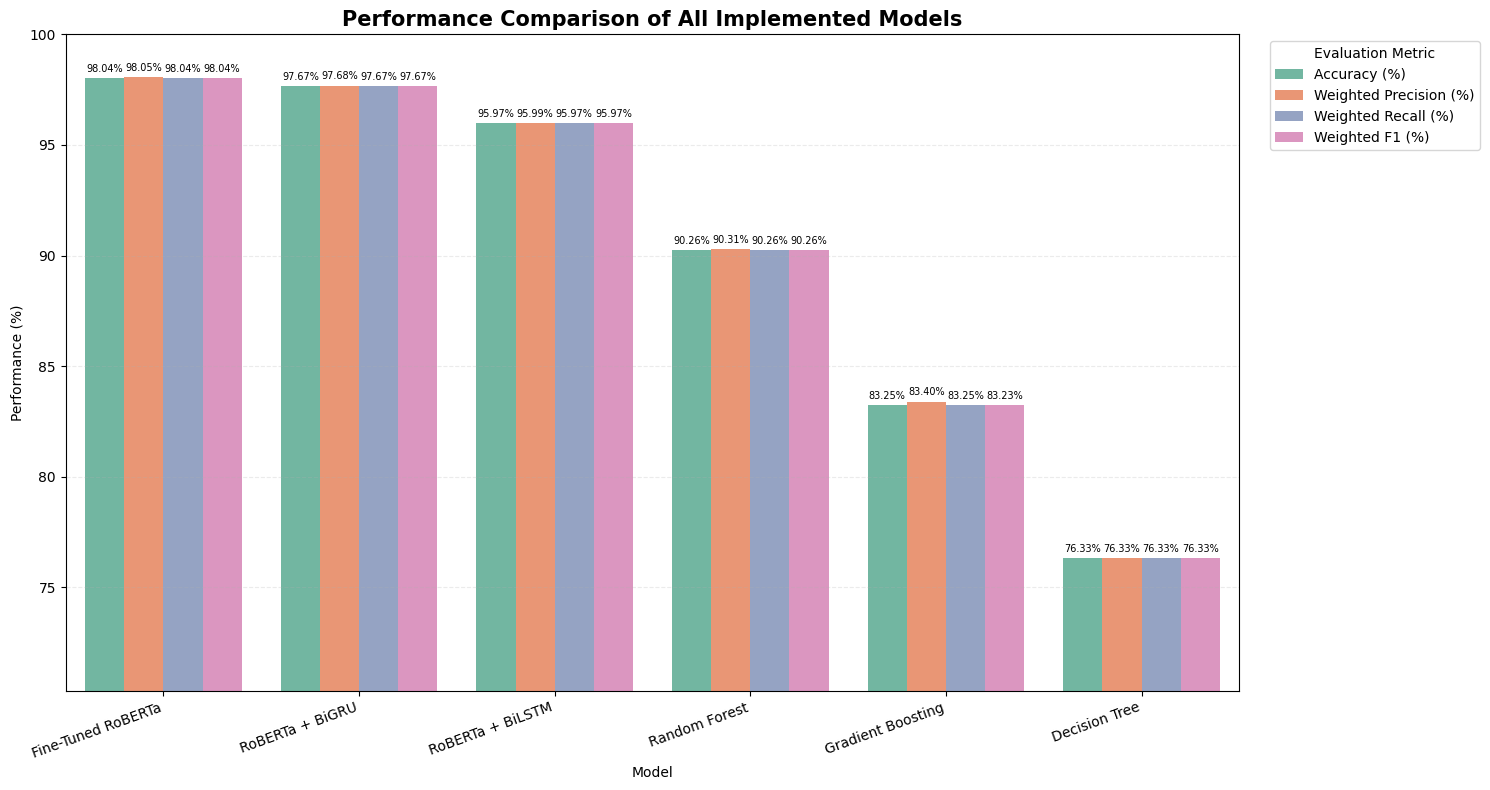

In [60]:
# Plot final model comparison
final_plot = final_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(15, 8))

ax = sns.barplot(
    data=final_plot,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title(
    "Performance Comparison of All Implemented Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Model")
plt.ylabel("Performance (%)")
plt.xticks(rotation=20, ha="right")

plt.ylim(
    max(
        0,
        final_plot["Score"].min() - 6
    ),
    100
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3,
        fontsize=7
    )

plt.legend(
    title="Evaluation Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

plt.tight_layout()
plt.show()
